## Importing libs and getting the dataset
<a id="Introduction"></a>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#pip install seaborn

In [3]:
# loading the dataset

file_path = r"./twitter_training.csv"
df = pd.read_csv(file_path , header = None ,names=['number' , 'Border' , 'label' , 'message']) # Adjusting the column names

### in this dataset we should build a model that can predict whether the sentence has a -ve or +ve or neutral effect based on the user's messages !

In [4]:
print(df.head())

   number       Border     label  \
0    2401  Borderlands  Positive   
1    2401  Borderlands  Positive   
2    2401  Borderlands  Positive   
3    2401  Borderlands  Positive   
4    2401  Borderlands  Positive   

                                             message  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [5]:
display(df['label'].value_counts())

label
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

## Okay let's drop the Useless columns

In [6]:
df.drop(['Border' , 'number'] , axis=1 , inplace = True)

In [7]:
# Shape ? 

df.shape

(74682, 2)

In [8]:
# Null values ? 

df.isnull().sum()

label        0
message    686
dtype: int64

## Let's Drop the null rows !

In [7]:
df.dropna(inplace = True)

In [10]:
df.shape

(73996, 2)

## Pre-Processing


In [8]:
df['message'] = df['message'].str.lower()

df.head()

,label,message
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,i am coming to the borders and i will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


### 2 - Removing HTML tags ! 

In [ ]:
#pip install beautifulsoup4

In [9]:
from bs4 import BeautifulSoup

def remove_html(text):

    clean_text = BeautifulSoup(text , 'html.parser')

    return clean_text.get_text()

In [10]:
df['message'] = df['message'].apply(remove_html)

display(df['message'].head(2))

C:\Users\98935\AppData\Local\Temp\ipykernel_23460\781006695.py:5: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a filename than HTML or XML.

If you meant to use Beautiful Soup to parse the contents of a file on disk, then something has gone wrong. You should open the file first, using code like this:

    filehandle = open(your filename)

You can then feed the open filehandle into Beautiful Soup instead of using the filename.

However, if you want to parse some data that happens to look like a filename, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  clean_text = BeautifulSoup(text , 'html.parser')


0    im getting on borderlands and i will murder yo...
1    i am coming to the borders and i will kill you...
Name: message, dtype: object

### 3 - Removing URLs (using regular expression (regex)

In [11]:
import re

def clean_url(text):
    
    return re.sub(r'http\S+|www\S+', '', text)

In [12]:
df['message'] = df['message'].apply(clean_url)

df.head()

,label,message
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,i am coming to the borders and i will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


### 4 - Removing punctuation

In [13]:
def remove_punctuation(text):
    
    return re.sub(r'[^\w\s]', '', text)

In [14]:
df['message'] = df['message'].apply(remove_punctuation)

df.head()

,label,message
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,i am coming to the borders and i will kill you...
2,Positive,im getting on borderlands and i will kill you all
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


### 5 - Removing Stop words

#### Stop words like : "the," "is," "and," "in," "on" don't add much of a value to the model in this task

In [ ]:
#!pip install spacy
#!python -m spacy download en_core_web_sm

In [15]:
import spacy

nlp = spacy.load("en_core_web_sm")

def remove_stopwords(text):
    if not isinstance(text, str):  # Handle non-string inputs
        return text
        
    doc = nlp(text)
    return " ".join([token.text for token in doc if not token.is_stop])

In [16]:
df['message'] = df['message'].apply(remove_stopwords)

In [ ]:
df.head() 

,label,message
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,i am coming to the borders and i will kill you...
2,Positive,im getting on borderlands and i will kill you all
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


### 6 - Removing Emojis !

In [ ]:
# pip install emoji

In [17]:
import emoji

def remove_emojis(text):
    return emoji.demojize(text)

df['message'] = df['message'].apply(remove_emojis)

### 7 - Lemmatization
#### changing the word back to its roots like : playing -> play , ate -> eat

In [18]:
def lemmatize_text(text):
    
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

df['message_lemmatized'] = df['message'].apply(lemmatize_text)

In [45]:
df.head()

,label,message,message_lemmatized
0,Positive,m getting borderlands murder,m get borderland murder
1,Positive,coming borders kill,come border kill
2,Positive,m getting borderlands kill,m get borderland kill
3,Positive,m coming borderlands murder,m come borderland murder
4,Positive,m getting borderlands 2 murder,m get borderland 2 murder


In [19]:
def clean_text(text):
    if not isinstance(text, str):  # Handle non-string inputs
        return text
    
    text = text.lower()  # 1️⃣ Convert to lowercase
    text = remove_html(text)  # 2️⃣ Remove HTML
    text = clean_url(text)  # 3️⃣ Remove URLs
    text = remove_punctuation(text)  # 4️⃣ Remove punctuation
    text = remove_stopwords(text)  # 5️⃣ Remove stopwords
    text = remove_emojis(text)  # 6️⃣ Remove emojis
    text = lemmatize_text(text)  # 7️⃣ Lemmatization
    
    return text

In [20]:
# let's give it a test !

new_text = "Heyyyy!!! 😊 Check this out: https://example.com <b>Awesome!</b>"
cleaned_text = clean_text(new_text)
print(cleaned_text)

heyyyy    check    awesome


## Word Cloud

In [ ]:
#!pip install WordCloud

In [21]:
from wordcloud import WordCloud

# Convert the column to a single string
text = df['message_lemmatized'].astype(str).str.cat(sep=" ")

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud

# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")
# plt.show()

### Now let's a word cloud of the +ve sentences and the -ve according to the data

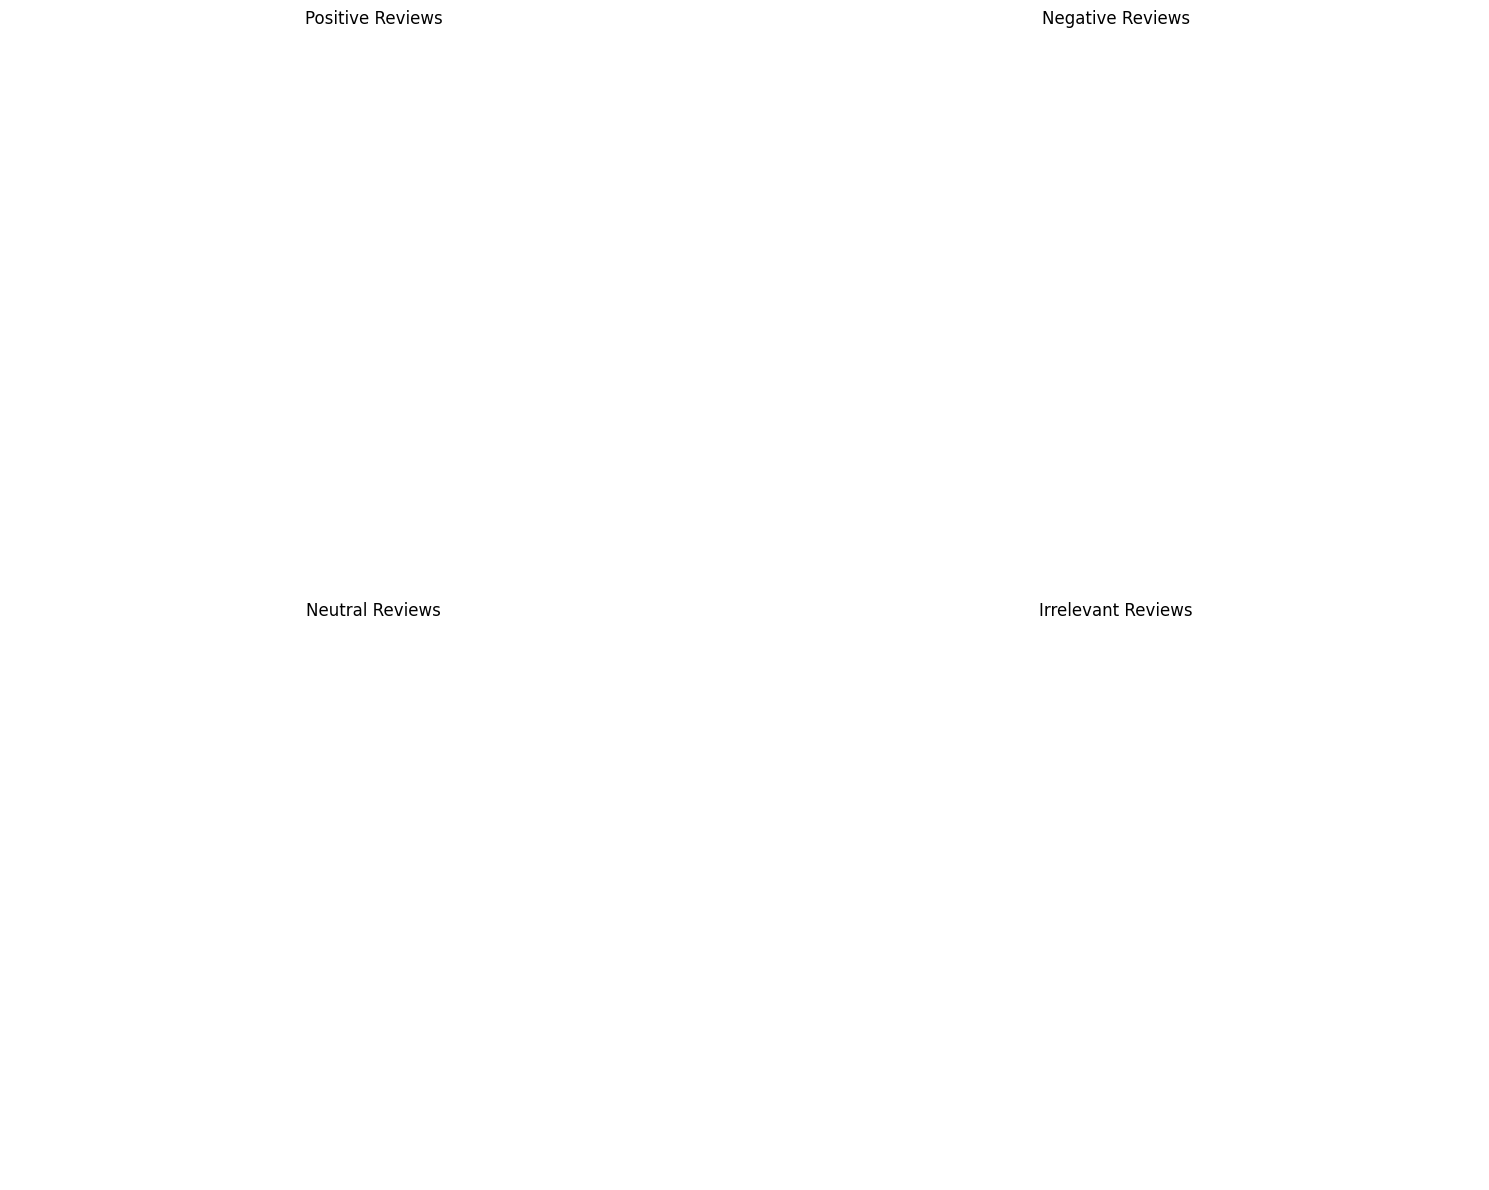

In [26]:
# Combine text data for each sentiment category
positive_text = " ".join(df[df["label"] == "Positive"]["message_lemmatized"])
negative_text = " ".join(df[df["label"] == "Negative"]["message_lemmatized"])
neutral_text = " ".join(df[df["label"] == "Neutral"]["message_lemmatized"])
irrelevant_text = " ".join(df[df["label"] == "Irrelevant"]["message_lemmatized"])

# Generate word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)
neutral_wordcloud = WordCloud(width=800, height=400, background_color='gray').generate(neutral_text)
irrelevant_wordcloud = WordCloud(width=800, height=400, background_color='lightgray').generate(irrelevant_text)

# Plot word clouds
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

#ax[0, 0].imshow(positive_wordcloud, interpolation='bilinear')
ax[0, 0].set_title("Positive Reviews")
ax[0, 0].axis("off")

#ax[0, 1].imshow(negative_wordcloud, interpolation='bilinear')
ax[0, 1].set_title("Negative Reviews")
ax[0, 1].axis("off")

#ax[1, 0].imshow(neutral_wordcloud, interpolation='bilinear')
ax[1, 0].set_title("Neutral Reviews")
ax[1, 0].axis("off")

#ax[1, 1].imshow(irrelevant_wordcloud, interpolation='bilinear')
ax[1, 1].set_title("Irrelevant Reviews")
ax[1, 1].axis("off")

plt.tight_layout()
plt.show()

## from this word cloud we can remove the word game as it's illogical to exist in every class !

In [27]:
df["message_lemmatized"] = df["message_lemmatized"].str.replace(r'\bgame\b', '', regex=True)

## Pre-Processing for the Target

In [28]:
# I'm going to mix the neutral class with the Irrelevant
df['label'] = df['label'].map({'Positive' : 1 ,  'Negative' : 0 ,'Neutral':2 , 'Irrelevant' : 2 })

In [29]:
df['label'].value_counts()

label
2    30983
0    22358
1    20655
Name: count, dtype: int64

## Split the data
#### into ( train , test and validation data ) 
#### since that there's imbalance in the target i'm going to use stratified sampling

In [30]:
from sklearn.model_selection import train_test_split

X = df['message_lemmatized'] # feature matrix ( in this case it's just a vectore cause it's only one column)
y = df['label'] # target column

X_train1 , X_test , y_train1 , y_test = train_test_split(X,y , random_state = 42 , test_size = 0.2  , shuffle = True)
X_train , X_val , y_train , y_val = train_test_split(X_train1 , y_train1 , random_state = 42 , test_size = 0.15  , shuffle = True)

In [31]:
X_train.shape , X_val.shape , X_test.shape , y_train.shape , y_val.shape , y_test.shape

((50316,), (8880,), (14800,), (50316,), (8880,), (14800,))

## Tokenization 
#### Converting words into numerical tokens

In [32]:
import tensorflow as tf

In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token = 'nothing')
tokenizer.fit_on_texts(X_train) # we call this method to build the tokenizer on the train data only to avoid data leakage !

In [74]:
#  returns the total number of documents (sentences) processed by the tokenizer
# just to make sure that all the sentences have been converted to tokens !

tokenizer.document_count

50316

### Conversion to sequence
#### used to convert each text in the data to sequences of integers based on the tokenizer's vocabulary

In [34]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_val_seq = tokenizer.texts_to_sequences(X_val)

### Padding
#### we apply padding on the data to ensure that each sequence is the same length !

In [35]:
# finding the max length
max_len = max(len(tokens) for tokens in X_train_seq)
print("Maximum sequence length (maxlen):", max_len)


Maximum sequence length (maxlen): 99


In [36]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Perform padding on X_train and X_test sequences and X_val

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len, padding='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

In [37]:
# Print the padded sequences for X_train and X_test
print("X_train_padded:")
print(X_train_padded[:1])
print("\nX_test_padded:")
print(X_test_padded[:1])
print("\nX_val_padded:")
print(X_val_padded[:1])

X_train_padded:
[[  34   92   62  301  686   34  396 1153  795    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0]]

X_test_padded:
[[  15    6  450  122  111  726 1377 1104   74  111  380 3323    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0  

### I was plannig to use Glove as a pretrained model for vector embeddings and then finetune it with my data
### but let's give training an embedding layer from scratch a try first !
### However with what we got so far we can train the model directly but LSTM works well with vector embeddings

In [38]:
# Define vocab size based on the tokenizer
vocab_size = len(tokenizer.word_index) + 1

print(vocab_size)

30940


## Model Building

In [39]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=100),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128 , return_sequences = True , dropout = 0.2 , recurrent_dropout = 0.2)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64 , dropout = 0.2 , recurrent_dropout = 0.2)),
    tf.keras.layers.Dense(64 , activation='relu'  , kernel_initializer = 'he_normal'),
    tf.keras.layers.Dense(3 , activation = 'softmax')

])

In [40]:
# defining callbacks for Early stopping and changing the learning rate while training 

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [41]:
# compiling the model 

# Compile Model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

In [42]:
with tf.device('/device:GPU:0'):
  # Train the Model
  history = model.fit(
      X_train_padded,  
      y_train,  
      validation_data=(X_val_padded, y_val),  # Validation set
      batch_size=32,  
      epochs=30,  
      callbacks=[early_stopping , reduce_lr],  # to Prevent overfitting
      verbose=1 
  )

Epoch 1/30


1573/1573 [==============================] - 8112s 5s/step - loss: 0.6837 - accuracy: 0.7024 - val_loss: 0.4956 - val_accuracy: 0.8014 - lr: 0.0010
Epoch 2/30
1573/1573 [==============================] - 956s 608ms/step - loss: 0.3331 - accuracy: 0.8688 - val_loss: 0.3853 - val_accuracy: 0.8526 - lr: 0.0010
Epoch 3/30
1573/1573 [==============================] - 964s 613ms/step - loss: 0.2178 - accuracy: 0.9132 - val_loss: 0.3684 - val_accuracy: 0.8671 - lr: 0.0010
Epoch 4/30
1573/1573 [==============================] - 1103s 702ms/step - loss: 0.1698 - accuracy: 0.9304 - val_loss: 0.3637 - val_accuracy: 0.8712 - lr: 0.0010
Epoch 5/30
1573/1573 [==============================] - 1038s 660ms/step - loss: 0.1446 - accuracy: 0.9406 - val_loss: 0.3709 - val_accuracy: 0.8765 - lr: 0.0010
Epoch 6/30
1573/1573 [==============================] - 1408s 895ms/step - loss: 0.1268 - accuracy: 0.9467 - val_loss: 0.4149 - val_accuracy: 0.8795 - lr: 0.0010
Epoch 7/30
1573/1573 [=========

In [43]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 100)         3094000   
                                                                 
 bidirectional (Bidirectiona  (None, None, 256)        234496    
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 128)              164352    
 nal)                                                            
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dense_1 (Dense)             (None, 3)                 195       
                                                                 
Total params: 3,501,299
Trainable params: 3,501,299
Non-

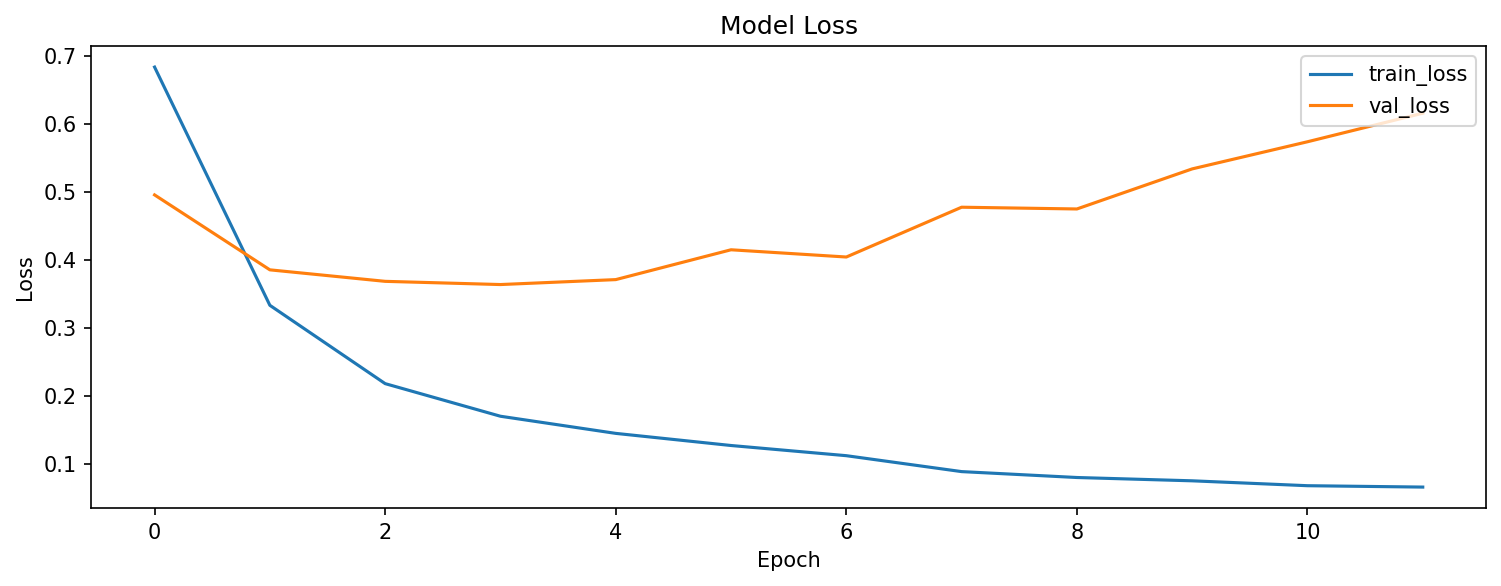

In [44]:

plt.figure(figsize=(12, 4), dpi=150)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


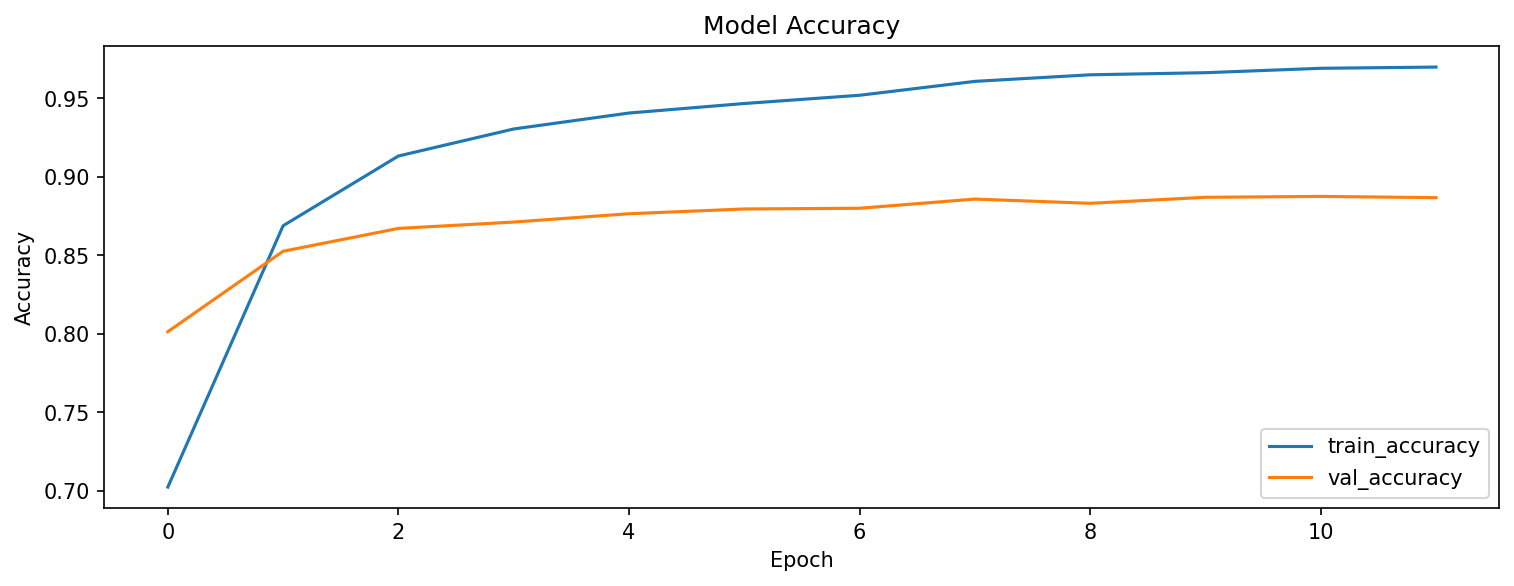

In [45]:
plt.figure(figsize=(12, 4), dpi=150)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

## Evaluation

In [46]:
# Get model predictions (probabilities)
y_probs = model.predict(X_test_padded)

# Converting probs into Binary values
y_pred = np.argmax(y_probs, axis=1)

463/463 [==============================] - 119s 251ms/step


In [93]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test_padded, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

463/463 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.8722 - loss: 0.3712
Loss: 0.3634290397167206, Accuracy: 0.8758783936500549


## Confusion Matrix

In [47]:
from sklearn.metrics import confusion_matrix , classification_report

cfm = confusion_matrix(y_test , y_pred)

In [48]:
# classification report
report = classification_report(y_test, y_pred)

# the report
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4380
           1       0.86      0.84      0.85      4119
           2       0.89      0.88      0.88      6301

    accuracy                           0.87     14800
   macro avg       0.87      0.87      0.87     14800
weighted avg       0.87      0.87      0.87     14800



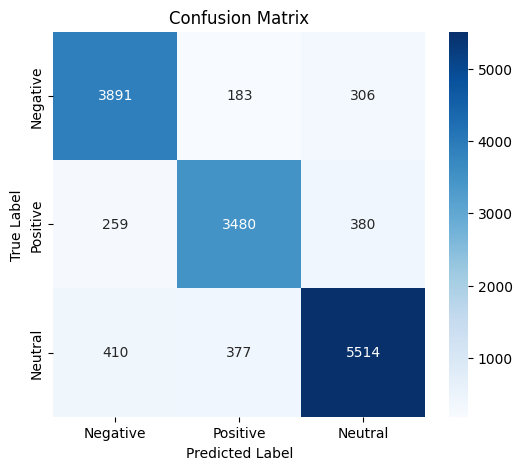

In [49]:
plt.figure(figsize=(6, 5))
sns.heatmap(cfm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative' , 'Positive' , 'Neutral'], yticklabels=['Negative' , 'Positive','Neutral'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### From the Confusion matrix we can conclude that the model is Okay !

## Saving the model and the tokenizer

In [50]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [51]:
# now the model 

model.save("LSTM_Sentiment_analysis.h5")

## Pre-Processing Pipeline for predictions

In [52]:
def preprocess_text(texts, tokenizer):
    """
    Preprocess new incoming text data.

    Args:
        texts (list of str): List of raw text inputs.
        tokenizer (Tokenizer): Pre-trained tokenizer.
        max_len (int): Maximum sequence length.

    Returns:
        np.array: Padded sequences ready for prediction.
    """
    # Convert text to sequences
    text_seq = tokenizer.texts_to_sequences(texts)
    
    # Apply padding
    text_padded = pad_sequences(text_seq, maxlen=max_len, padding="post")
    
    return text_padded

In [53]:
def Predict(text , model , tokenizer):
    
    text = [text]
    text = clean_text(text)
    text_padded =  preprocess_text(text , tokenizer)

    y_prob = model.predict(text_padded)
   
    y_pred = np.argmax(y_prob, axis=1)

    classes = ['Negative' , 'Positive' , 'Neutral']

    pred_class = classes[y_pred[0]]  # Get predicted class label
    pred_prob = y_prob[0][y_pred[0]] # get predicted prob


    return pred_class, pred_prob

## Loading the model
## Now if u want to use the model again without training it again
### you can simply load it with the tokenzier

In [ ]:
# loading the tokenizer

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)


# Load the saved model
#/kaggle/working/
loaded_model = tf.keras.models.load_model('LSTM_Sentiment_analysis.h5')

In [58]:
new_text = "this movie was very good and really loved it and it is very good would great watch it again because it was amazing great"

pred_class  , prob  = Predict(new_text , loaded_model , tokenizer)


1/1 [==============================] - 0s 428ms/step


In [59]:
print(f"Class Prediction is : {pred_class} with Probabilty {prob}")

Class Prediction is : Positive with Probabilty 0.9742748737335205
